In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [13]:
img1 = cv2.imread(r"C:\Users\HP\Downloads\images.jpg")   
if img is None:
    print("Image not found. Check the file path.")
else:

    # Resize to 5x5 so that matrices can be printed clearly
    img = cv2.resize(img1, (5, 5))

    print("=" * 60)
    print("ORIGINAL IMAGE MATRIX")
    print("=" * 60)
    print(img)


ORIGINAL IMAGE MATRIX
[[[111 125 128]
  [106 151 220]
  [119 128 168]
  [ 85 118 192]
  [ 95  94 105]]

 [[129 140 130]
  [163 186 182]
  [160 215 250]
  [140 214 248]
  [ 78 168 231]]

 [[ 76  67  64]
  [ 57  64  73]
  [ 42  89 142]
  [ 52 155 215]
  [ 44 125 191]]

 [[ 37  60  45]
  [ 29 152 169]
  [ 37 195 217]
  [ 27  84 100]
  [ 34  78  85]]

 [[  4  60  31]
  [ 27  71  64]
  [ 49 118 102]
  [ 10  67  42]
  [ 43 104  98]]]


In [5]:
# ROBERTS FILTER
roberts_x = np.array([
        [1, 0],
        [0, -1]
    ], dtype=np.float32)

roberts_y = np.array([
        [0, 1],
        [-1, 0]
    ], dtype=np.float32)

rx = cv2.filter2D(img, cv2.CV_64F, roberts_x)
ry = cv2.filter2D(img, cv2.CV_64F, roberts_y)

roberts_magnitude = np.sqrt(rx**2 + ry**2)

roberts_theta = np.degrees(
        np.arctan2(ry, rx)
    )

roberts_theta[roberts_theta < 0] += 180

In [6]:
#Prewitt Filter
prewitt_x = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ], dtype=np.float32)

prewitt_y = np.array([
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1]
    ], dtype=np.float32)

px = cv2.filter2D(img, cv2.CV_64F, prewitt_x)
py = cv2.filter2D(img, cv2.CV_64F, prewitt_y)

prewitt_magnitude = np.sqrt(px**2 + py**2)

prewitt_theta = np.degrees(
        np.arctan2(py, px)
    )

prewitt_theta[prewitt_theta < 0] += 180

In [7]:
#Sobell filter
sx = cv2.Sobel(
        img,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )
sy = cv2.Sobel(
        img,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )
sobel_magnitude = np.sqrt(sx**2 + sy**2)

sobel_theta = np.degrees(
        np.arctan2(sy, sx)
    )

sobel_theta[sobel_theta < 0] += 180

In [8]:
#Robert Matrix Result
print("\n" + "=" * 60)
print("ROBERTS FILTER")
print("=" * 60)

print("\nRoberts Gx:")
print(np.round(rx, 2))

print("\nRoberts Gy:")
print(np.round(ry, 2))

print("\nRoberts Magnitude:")
print(np.round(roberts_magnitude, 2))

print("\nRoberts Theta (degrees):")
print(np.round(roberts_theta, 2))


ROBERTS FILTER

Roberts Gx:
[[[  52.   61.   54.]
  [  23.  -11.  -90.]
  [  44.   58.   14.]
  [  75.   97.   58.]
  [  45.  120.  143.]]

 [[ -23.   11.   90.]
  [ -52.  -61.  -54.]
  [ -54.  -64.  -30.]
  [ -21.  -86.  -80.]
  [   7.  -50.  -39.]]

 [[  87.  119.  118.]
  [  72.   76.   57.]
  [ 121.   97.   40.]
  [ 108.   60.   35.]
  [  96.   89.   57.]]

 [[  20.    4.   28.]
  [  47.  -85. -105.]
  [  20. -131. -144.]
  [  15.    5.   42.]
  [  18.   77.  130.]]

 [[  25.   92.  138.]
  [  10.  -11.  -19.]
  [ -20.   34.   67.]
  [  27.  128.  175.]
  [ -16.  -20.    2.]]]

Roberts Gy:
[[[  23.  -11.  -90.]
  [  52.   61.   54.]
  [  54.   64.   30.]
  [  21.   86.   80.]
  [  -7.   50.   39.]]

 [[ -52.  -61.  -54.]
  [ -23.   11.   90.]
  [ -44.  -58.  -14.]
  [ -75.  -97.  -58.]
  [ -45. -120. -143.]]

 [[  72.   76.   57.]
  [  87.  119.  118.]
  [ 103.  151.  177.]
  [  98.  125.  106.]
  [  26.   13.   16.]]

 [[  47.  -85. -105.]
  [  20.    4.   28.]
  [  13.  -63.  -2

In [9]:
#Prewitt Matrix
print("\n" + "=" * 60)
print("PREWITT FILTER")
print("=" * 60)

print("\nPrewitt Gx:")
print(np.round(px, 2))

print("\nPrewitt Gy:")
print(np.round(py, 2))

print("\nPrewitt Magnitude:")
print(np.round(prewitt_magnitude, 2))

print("\nPrewitt Theta (degrees):")
print(np.round(prewitt_theta, 2))


PREWITT FILTER

Prewitt Gx:
[[[   0.    0.    0.]
  [  70.  153.  280.]
  [ -67.   23.  104.]
  [-188. -128. -101.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [   5.  100.  238.]
  [ -49.   86.  180.]
  [-104.  -45.  -33.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [  -3.  232.  370.]
  [ -30.   51.  139.]
  [ -83. -128. -102.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [  11.  215.  321.]
  [ -24.   19.   51.]
  [  -7.  -95.  -87.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [  45.  328.  415.]
  [ -21. -140. -160.]
  [ -12. -248. -268.]
  [   0.    0.    0.]]]

Prewitt Gy:
[[[   0.    0.    0.]
  [   0.    0.    0.]
  [   0.    0.    0.]
  [   0.    0.    0.]
  [   0.    0.    0.]]

 [[-133. -232. -358.]
  [-161. -184. -237.]
  [-159.  -89. -150.]
  [-161.   29.   83.]
  [-117.  105.  132.]]

 [[-360. -148. -111.]
  [-349. -134. -131.]
  [-370. -184. -194.]
  [-280. -240. -327.]
  [-270. -350. -442.]]

 [[-132.    7.  -51.]
  [ -95.   29.  -82.]
  [ -65.  -52. -22

In [10]:
#Sobel Filter
print("\n" + "=" * 60)
print("SOBEL FILTER")
print("=" * 60)

print("\nSobel Gx:")
print(np.round(sx, 2))

print("\nSobel Gy:")
print(np.round(sy, 2))

print("\nSobel Magnitude:")
print(np.round(sobel_magnitude, 2))

print("\nSobel Theta (degrees):")
print(np.round(sobel_theta, 2))


SOBEL FILTER

Sobel Gx:
[[[   0.    0.    0.]
  [  78.  156.  320.]
  [ -88.  -10.   76.]
  [-212. -162. -164.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [  36.  175.  358.]
  [ -72.  114.  246.]
  [-186.  -92.  -52.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [ -37.  254.  448.]
  [ -35.  142.  281.]
  [ -81.  -92.  -53.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [  11.  350.  493.]
  [ -26.  -49.  -18.]
  [ -10. -212. -219.]
  [   0.    0.    0.]]

 [[   0.    0.    0.]
  [  90.  386.  486.]
  [ -38. -144. -182.]
  [ -18. -262. -272.]
  [   0.    0.    0.]]]

Sobel Gy:
[[[   0.    0.    0.]
  [   0.    0.    0.]
  [   0.    0.    0.]
  [   0.    0.    0.]
  [   0.    0.    0.]]

 [[-168. -290. -422.]
  [-210. -271. -384.]
  [-236. -128. -176.]
  [-194.   66.  106.]
  [-168.  136.  218.]]

 [[-452. -228. -196.]
  [-483. -168. -144.]
  [-493. -204. -227.]
  [-393. -370. -475.]
  [-314. -440. -588.]]

 [[-204.    0.  -84.]
  [-125.   36.  -91.]
  [ -58.  -23. -262.]
  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [21.213203435596427..181.46349495146399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..442.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..588.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.310277167524195..179.3452195977323].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..180.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..180.0].


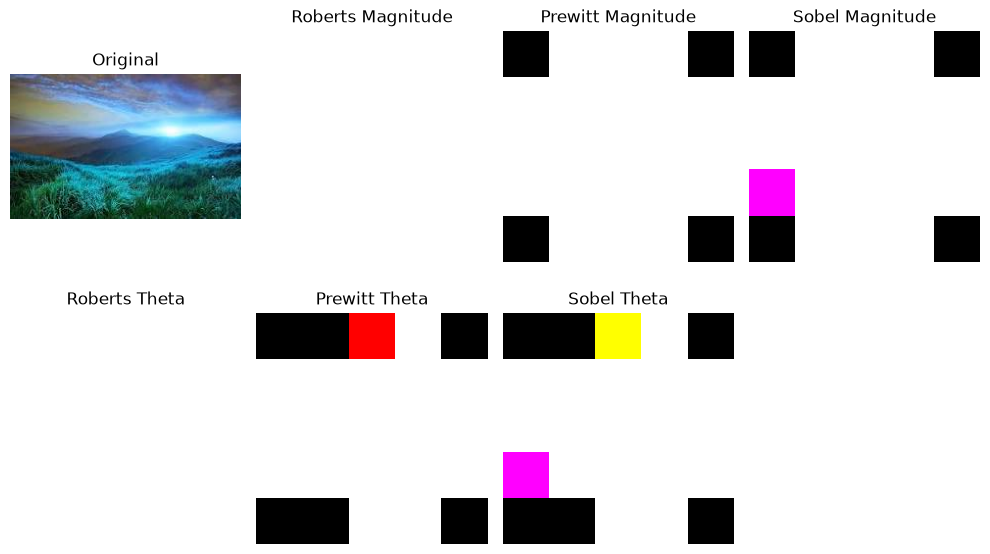

In [14]:
plt.figure(figsize=(10, 6))

    # Original
plt.subplot(2, 4, 1)
plt.imshow(img1)
plt.title("Original")
plt.axis("off")

    # Roberts
plt.subplot(2, 4, 2)
plt.imshow(roberts_magnitude, cmap="gray")
plt.title("Roberts Magnitude")
plt.axis("off")

    # Prewitt
plt.subplot(2, 4, 3)
plt.imshow(prewitt_magnitude, cmap="gray")
plt.title("Prewitt Magnitude")
plt.axis("off")

    # Sobel
plt.subplot(2, 4, 4)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Magnitude")
plt.axis("off")

    # Roberts Theta
plt.subplot(2, 4, 5)
plt.imshow(roberts_theta, cmap="gray")
plt.title("Roberts Theta")
plt.axis("off")

    # Prewitt Theta
plt.subplot(2, 4, 6)
plt.imshow(prewitt_theta, cmap="gray")
plt.title("Prewitt Theta")
plt.axis("off")

    # Sobel Theta
plt.subplot(2, 4, 7)
plt.imshow(sobel_theta, cmap="gray")
plt.title("Sobel Theta")
plt.axis("off")

plt.tight_layout()
plt.show()